In [1]:
from torchvision import datasets, transforms, models 
from torch.utils.data import DataLoader,WeightedRandomSampler,SubsetRandomSampler, Subset, Dataset
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import os
from PIL import Image
import pandas as pd

### Apply different transforms to augment the dataset

The transforms are done online when called by the DataLoader, so every time its called to generate a batch the transforms are applied randomly,
which allows the model to see the same image differently almost every epoch

In [2]:
train_transforms = transforms.Compose([
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5, fill=128), #augmentation
    transforms.RandomRotation(10), #augmentation
    transforms.RandomResizedCrop(size=(256,256), scale=(0.5, 1.0), ratio=(0.75, 1.33)), #resizing is essential but cropping is augmentation
    transforms.RandomHorizontalFlip(0.5), #augmentation
    transforms.ColorJitter(brightness=0.1, contrast=0.1), #augmentation 
    transforms.ToTensor(), #essential
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Read the data

In [3]:
#Read it twice because each one has different transforms
trainDataset = datasets.ImageFolder(root='/kaggle/input/nn-26-scene-style-classification/StyleClassificationIndoors/StyleClassificationIndoors/train', transform=train_transforms)
valDataset   = datasets.ImageFolder(root='/kaggle/input/nn-26-scene-style-classification/StyleClassificationIndoors/StyleClassificationIndoors/train', transform=val_transforms)

targets = trainDataset.targets
#split by index, not the actual data
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), 
    test_size=0.2,           #80/20 split
    shuffle=True, 
    stratify=targets     #to keep the same distribution of classes in both sets
)

train_subset = Subset(trainDataset, train_idx)
val_subset   = Subset(valDataset, val_idx)


The boho and the minimalist classes are outliers in the terms of number of images. boho: 918, minimalist: 555

In [4]:
counter = Counter(trainDataset.targets)
for class_index, count in counter.most_common():
    class_name = trainDataset.classes[class_index]
    print(f"{class_name}: {count}")

boho: 918
eclectic: 809
modern: 809
farmhouse: 795
coastal: 794
mediterranean: 789
french-country: 788
contemporary: 782
asian: 779
southwestern: 772
tropical: 772
scandinavian: 768
craftsman: 764
industrial: 764
victorian: 759
shabby-chic-style: 746
minimalist: 555


Balance only the training dataset using a weighted random sampler

In [5]:
train_targets = np.array(targets)[train_idx] #get all the training targets

#calculate the weights
class_counts = np.bincount(train_targets)
class_weights = 1. / class_counts

#map each label to its weight
sample_weights = class_weights[train_targets] #this create an array of len(train_targets), and its like every we are indexing by the target label 
sample_weights = torch.from_numpy(sample_weights).double()

train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [6]:
train_loader = DataLoader(
    train_subset, 
    batch_size=32, 
    sampler=train_sampler,
    num_workers=4
)

val_loader = DataLoader(
    val_subset, 
    batch_size=32, 
    shuffle=False,        
    num_workers=4
)

In [7]:
print(f"Training on {len(train_subset)} images.")
print(f"Validating on {len(val_subset)} images.")

Training on 10530 images.
Validating on 2633 images.


### Visualize a batch

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

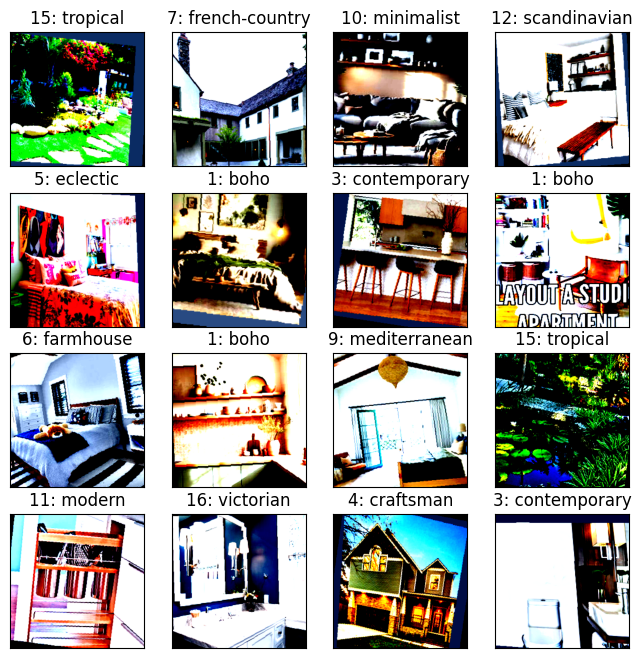

In [8]:
indoorStyleClasses = trainDataset.classes

data_iter = iter(train_loader)
images, labels = next(data_iter)

fig = plt.figure(figsize=(8, 8))

for i in range(16):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    
    img_display = images[i].numpy().transpose((1, 2, 0))
    plt.imshow(img_display)
    idx = labels[i].item()
    real_name = indoorStyleClasses[idx]
    
    ax.set_title(f"{idx}: {real_name}")

plt.show()

In [9]:
# ![image.png](attachment:86e5d14c-b8e3-470d-bd80-3e410b7e035a.png)

In [10]:
class VGG16(nn.Module):
    def __init__(self, num_classes=17):
        super(VGG16, self).__init__()

        #VGG16 , but with batch normaliztion
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        #wasn't in the orig paper
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) 
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),  
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),      
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

In [11]:
model = VGG16(len(trainDataset.classes))    

In [12]:
#download image net pretrained weights and load them
pretrained_weights = models.vgg16_bn(weights=models.VGG16_BN_Weights.IMAGENET1K_V1).state_dict()
model.load_state_dict(pretrained_weights, strict=False)

# freeze the trained layers, now only the classifier(head) gets trained
for param in model.features.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth
100%|██████████| 528M/528M [00:02<00:00, 244MB/s]


In [13]:
import time
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    # Lists to store metrics for plotting later
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            # (We don't need tqdm here if on Kaggle, prints are cleaner)
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                # Track history only if in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Store history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                # Update Scheduler
                if scheduler:
                    scheduler.step(epoch_loss)

                # Deep Copy the model if it's the best one so far
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    # Save checkpoint immediately
                    torch.save(model.state_dict(), 'best_model.pth')

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [14]:
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
# Reduces LR if validation loss stops improving for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
model.to(device)

model, history = train_model(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    num_epochs=50 
)

Epoch 1/50
----------
train Loss: 2.6435 Acc: 0.1661
val Loss: 2.3904 Acc: 0.2434

Epoch 2/50
----------
train Loss: 2.3132 Acc: 0.2622
val Loss: 2.2215 Acc: 0.2746

Epoch 3/50
----------
train Loss: 2.2016 Acc: 0.2938
val Loss: 2.1098 Acc: 0.3122

Epoch 4/50
----------
train Loss: 2.1396 Acc: 0.3155
val Loss: 2.0962 Acc: 0.3205

Epoch 5/50
----------
train Loss: 2.0903 Acc: 0.3224
val Loss: 2.1227 Acc: 0.3111

Epoch 6/50
----------
train Loss: 2.0923 Acc: 0.3267
val Loss: 2.0870 Acc: 0.3247

Epoch 7/50
----------
train Loss: 2.0471 Acc: 0.3435
val Loss: 2.0013 Acc: 0.3471

Epoch 8/50
----------
train Loss: 2.0298 Acc: 0.3423
val Loss: 2.0068 Acc: 0.3536

Epoch 9/50
----------
train Loss: 2.0196 Acc: 0.3486
val Loss: 2.0885 Acc: 0.3240

Epoch 10/50
----------
train Loss: 1.9878 Acc: 0.3538
val Loss: 1.9643 Acc: 0.3707

Epoch 11/50
----------
train Loss: 2.0150 Acc: 0.3507
val Loss: 1.9852 Acc: 0.3604

Epoch 12/50
----------
train Loss: 1.9560 Acc: 0.3700
val Loss: 1.9942 Acc: 0.3532

E

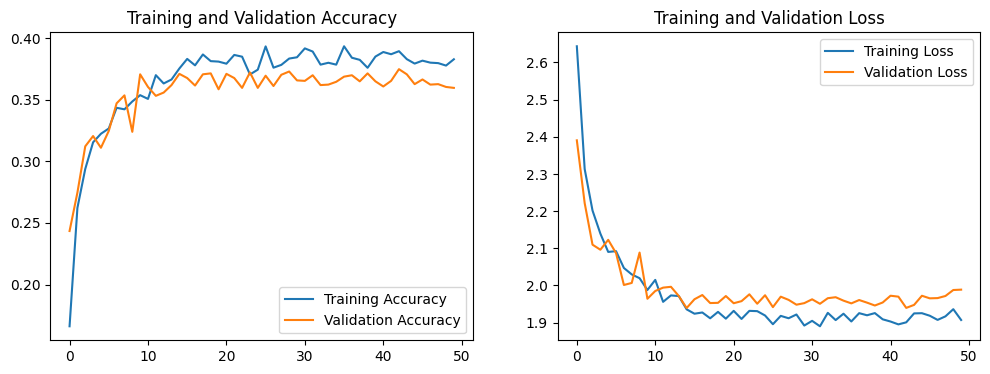

In [17]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_history(history)

In [18]:
class KaggleTestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Find all valid images
        self.images = os.listdir(root_dir)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except (OSError, Image.UnidentifiedImageError):
            print(f"{img_name} is corrupt and will be replaced with a black image.")
            image = Image.new('RGB', (256, 256), color='black')
        image = self.transform(image)

        return image, img_name

In [19]:
test_dataset = KaggleTestDataset(root_dir="/kaggle/input/nn-26-scene-style-classification/StyleClassificationIndoors/StyleClassificationIndoors/test", transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [20]:
predictions = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted_indices = torch.max(outputs, 1)
        
        predicted_indices = predicted_indices.cpu().tolist()
        
        for filename, idx in zip(filenames, predicted_indices):
            predictions.append({'ImageName': filename, 'Category': idx})

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


testimage_4180.jpg is corrupt and will be replaced with a black image.
testimage_1881.jpg is corrupt and will be replaced with a black image.
testimage_3427.jpg is corrupt and will be replaced with a black image.
testimage_3341.jpg is corrupt and will be replaced with a black image.


In [21]:
df = pd.DataFrame(predictions)
df.to_csv('submission.csv', index=False)

In [22]:
df['Category'].value_counts()

Category
10    1236
11     473
2      376
5      367
15     355
1      308
7      280
8      274
14     259
4      255
0      241
16     228
6      200
12     194
13     184
9      166
3       86
Name: count, dtype: int64